# 第8回講義 演習

今回は，まず**GPT (Generative Pre-trained Transformer)** [[1] [2]](#scrollTo=zYDroE-YWKpi) のモデルを実装し，訓練と文章生成を行います．  
そしてTransformerを画像タスクに応用した**ViT(Vision Transformer)** [[7]](#scrollTo=zYDroE-YWKpi)を実装し訓練します．

## 目次

[【課題】GPTとViTの実装と学習](#scrollTo=Pu2j3oP-ngYa)

1. [準備](#scrollTo=FnaO0pkiXorH)
2. [GPTモデルの実装](#scrollTo=HKH6r5-jT9B1)

  2.1.[GPTの概要](#scrollTo=iGILrcVFGGKW)

  2.2.[GPTのアーキテクチャ：Transformer decoder](#scrollTo=KLe2_Uh7U3j5)

  2.3.[Multi-Head Attention](#scrollTo=5r3ucwy-VZQR)

  2.4.[ブロックの定義](#scrollTo=RKs6mWpTkcvA)

  2.5.[GPTモデルの実装](#scrollTo=sAZyzccunZRw)

3. [文章生成](#scrollTo=fgBvrxC4ZCQy)
4. [ViTの実装](#scrollTo=xE8nzrUWx5mR)

  4.1.[PatchEmbeddingの実装](#scrollTo=XSW1iAql5m4h)

  4.2.[ViTの実装](#scrollTo=CqGICXBk6Yi7)

  4.3.[ViTの学習](#scrollTo=moNlU8l061nA)

　 [参考文献](#scrollTo=zYDroE-YWKpi)

## 【課題】GPTとViTの実装と学習

## 1.準備

演習を行うための準備をしていきましょう．

In [ ]:
from google.colab import drive
# drive.flush_and_unmount()
drive.mount("/content/drive", force_remount=True)

In [ ]:
# Lecture08が配置されているディレクトリを指定してください
work_dir = '/content/drive/MyDrive/Colab Notebooks/DLBasics2025_colab/Lecture08'

import os
os.chdir(work_dir)
print(os.getcwd())

!sudo apt update
!sudo apt install xvfb

import sys
import random
import math
import numpy as np
from tqdm.notebook import tqdm
import h5py
from os.path import join
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms
from einops.layers.torch import Rearrange
from einops import rearrange, repeat

import logging

import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from torch.nn import functional as F

seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.set_printoptions(edgeitems=1e3)

DEVICE = 'cuda'

# 要素にドットでアクセスできる辞書クラス
class Args(dict):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.__dict__ = self

GPUが利用できていることを確認しておきます.

In [ ]:
# GPUの情報を確認
!nvidia-smi

In [ ]:
torch.cuda.is_available()

In [ ]:
torch.__version__

## 2.GPTモデルの実装

### 2.1.GPTの概要

**事前学習**

GPTにおけるgenerative pre-trainingとは，シークエンスにおいて以前のトークン列から，マスクされた次のトークンの尤度を最大化するように学習を行うことです．

$$
L = \sum_i\log P(u_{i}|u_{i-k},...,u_{i-1})
$$

- 実装上はattention mapの右上をマスキングし (causal masking)，並列にモデリングを行います．

- $k$はcontext window sizeなどと呼ばれます．

<!--

<br>

**ファインチューニング** (補足)

事前学習のあと，文章分類や要約など個別のタスクに応じた（教師あり）データでファインチューニングを行うことができます．

その際，モデルの構造は最後に線形層を加える程度の変更でよく，それぞれのタスクに応じた形にシークエンスを編集することで，（教師あり）学習を行うことができます.

ファインチューニングで最大化したい目的関数も示しておきます．

$$
L_2(\mathcal{C}) = \sum_{x,y}\log P(y|x^1,...,x^m)
$$

<figure align='center'><img src='https://github.com/SeanNobel/world_model/blob/main/fine-tuning.png?raw=True' width='60%'><figcaption>Radford et al. 2018</figcaption></figure>

- $L_1 + L_2$がGPT全体の目的関数と表されます．

- ただし，本演習ではファインチューニングは行いません．

<!--
本演習では, GPTのモデル（Transformerのデコーダ部分）を実装し, 事前学習を行います.

前半では目的が文章生成のため, ファインチューニングは行いません.  
後半のTrajectory Transformerでは, 他のエージェントがたどった状態, 行動, 報酬のシークエンスを入力としてGPTモデルを訓練します（これも事前学習に近い）.
-->

### 2.2.GPTのアーキテクチャ：Transformer decoder

**Transformerのアーキテクチャ**

Transformer [[4]](#scrollTo=zYDroE-YWKpi) はもともと言語翻訳の文脈で提案されたもののため，図のようなソース言語とターゲット言語の入力に対応したencoder-decoder構造を取ります．

Encoder, decoderともにMulti-Head AttentionとFeed Forwardを含んだブロックがM回繰り返されたような構造になっています．
- $N$: vocabulary
- $n$: context size
- $d_{model}$: embedding次元数

<!--
<figure><img src='https://github.com/SeanNobel/world_model/blob/main/transformer_architecture_ver3.jpeg?raw=True' width='50%'><figcaption>Modified from Vaswani et al. 2017</figcaption></figure>
-->

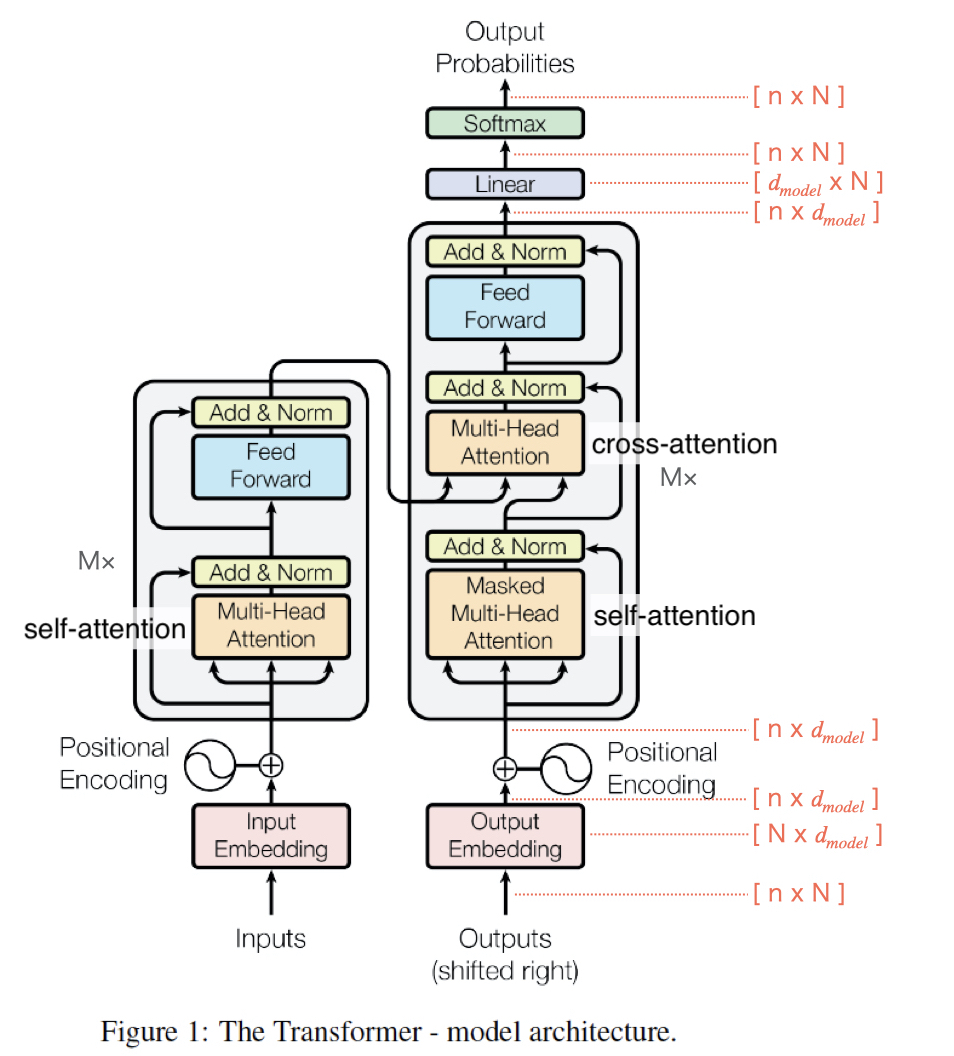<figcaption>Modified from Vaswani et al. 2017</figcaption>

<br>

**GPTのアーキテクチャ**

GPTでは，Transformerのdecoder部分のみを用います．

- Encoderからの入力を受け取るcross-attentionがないという形になります．

<!--
<figure><img src='https://github.com/SeanNobel/world_model/blob/main/GPT_arch.png?raw=True' width='20%'><figcaption>Radford et al. 2018</figcaption></figure>
-->

- Transformerの図においてNorm (= layer normalization)がAttentionやFeed Forwardの後にありますが，GPT-2以降はlayer normalizationをそれらの前に置くことが多くなりました．本演習でも後者に則り実装を行います．


### 2.3.Multi-Head Attention

Transformer [[4]](#scrollTo=zYDroE-YWKpi) のポイントであるAttentionは，以下のように行列積で記述されます．

**Attention** (Scaled Dot-Product Attention)

$$
Attention(Q, K, V) = softmax \left( \frac{QK^\top}{\sqrt{d_k}} \right) V  
$$

- ここで使われる$Q$ (query), $K$ (keys), $V$ (values)は，Attention層への入力系列$X \in \mathbb{R}^{n \times d_{model}}$をそれぞれ$W^Q, W^K, W^V$で線形変換したものです．

<!--
Multi-Head Attention層への入力はQue, Key, Valueの3つに分かれます. ブロックへの入力を$X$としたとき, それぞれの全結合層で$X$を変換したものとして計算されます. このQuery, Key, Valueを用いて, **Attention**が計算されます.
-->

$$
Q = XW^Q,\quad K = XW^K,\quad V = XW^V
$$

$$
W^Q, W^K \in \mathbb{R}^{d_{model} \times d_k}, W^V \in \mathbb{R}^{d_{model} \times d_v}
$$

- $softmax \left( \frac{QK^\top}{\sqrt{d_k}} \right)$ は，$V$に掛ける重みと考えられます．$Q$ と $K$ の類似度から，$V$ のどこが重要であるか（注目すべきか）を計算していると言えます．

<!--
  - $Q$ と $K$ が高次元のとき（$d_k$が大きいとき）ソフトマックスの入力が非常に勾配の小さい領域とならないよう，$\sqrt{d_k}$でスケールをしています．
-->

<br>

**Multi-Head Attention**

Multi-Head Attentionは，複数のAttentionを結合してから全結合層に通したものです．

<br>

\begin{align}
MultiHeadAttention(Q, K, V) &= concat(head_1, ..., head_h)\, W^O \\
ただし &\;head_i = Attention(QW_i^Q, KW_i^K, VW_i^V) \\\\
W_i^Q \in \mathbb{R}^{d_{model} \times d_k}, \quad W_i^K \in & \mathbb{R}^{d_{model} \times d_k}, \quad W_i^V \in \mathbb{R}^{d_{model} \times d_v}, \quad W^O \in \mathbb{R}^{hd_v \times d_{model}}
\end{align}

<br>

<!--
下図右のように, $V$, $K$, $Q$それぞれについてさらに全結合層を$h$個用意し, $d_{model}$の次元を$d_v$や$d_k$に圧縮します. $h$個のAttentionがパラレルに計算され, これらをconcatenationして全結合層で再度変換したものが, Multi-Head Attentionの出力となります.
-->

- 複数のヘッドを用意することで，それぞれが文章の違う領域に注意を向けて情報を取ってこれるという利点があります．

  - $d_{model}$: embedding空間の次元数
  - $d_v$: $V$の次元数
  - $d_k$: $Q$と$K$の次元数
  - $n$: コンテクストサイズ
  - $h$: ヘッド数

<figure align='center'><img src=' 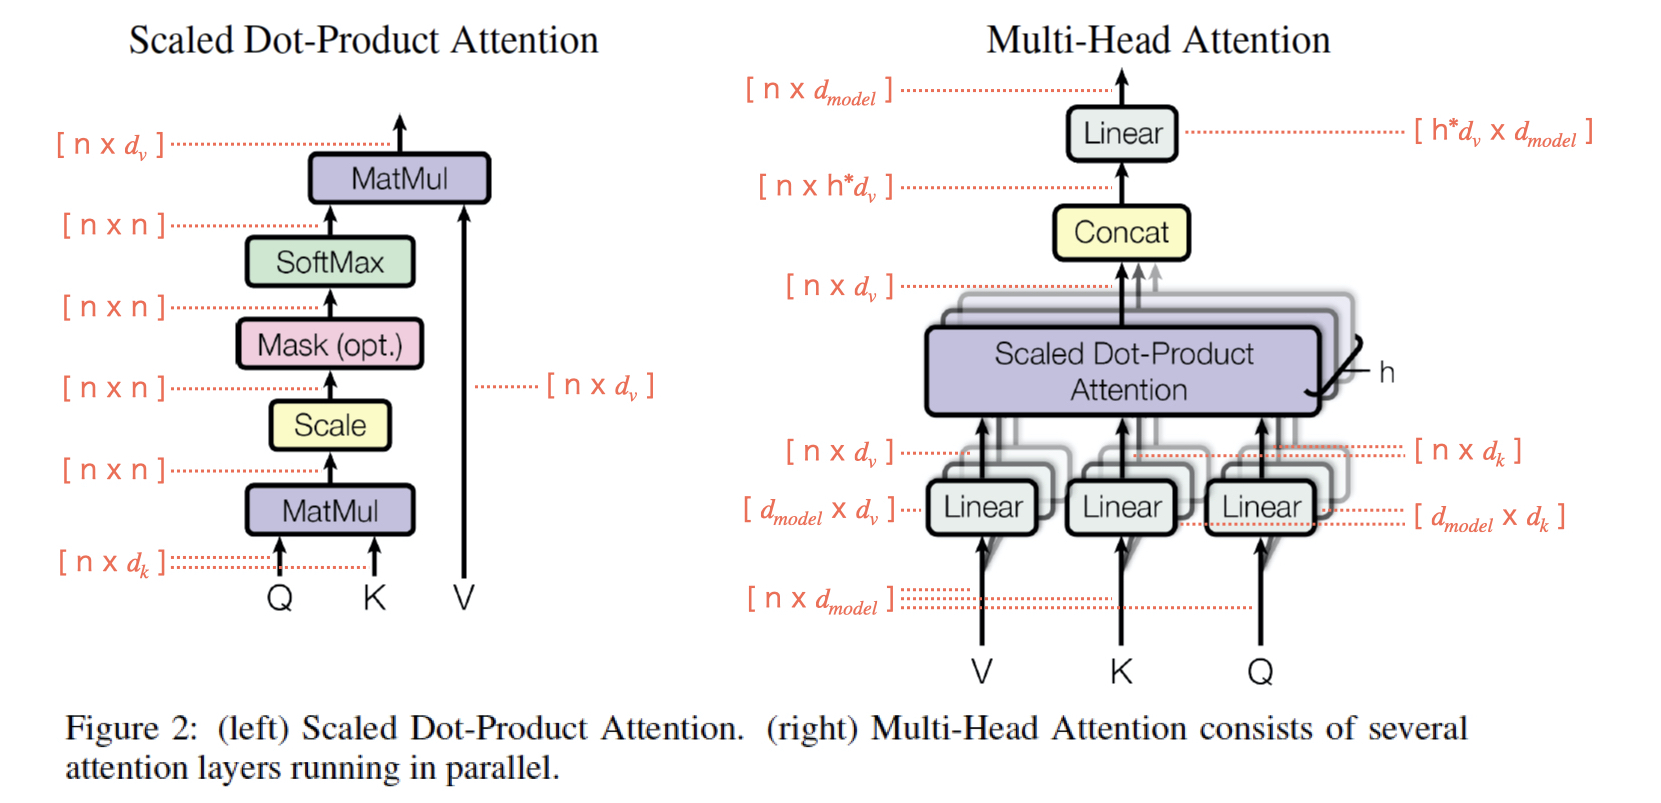' width='80%'><figcaption>Modified from Vaswani et al. 2017</figcaption></figure>

In [ ]:
class SelfAttention(nn.Module):
    """ self-attention """
    def __init__(self, config, resid_pdrop=0.1, attn_pdrop=0.1, causal=True) -> None:
        """
        Parameters
        ----------
        resid_pdrop : float
            出力projection層のドロップアウト率
        attn_pdrop : float
            Attentionのドロップアウト率
        causal : bool
            causal maskを利用するかどうか判別するフラグ
        """
        super().__init__()
        assert config.n_embd % config.n_head == 0

        # 入力をK, Q, Vにそれぞれ変換する全結合層
        self.key = nn.Linear(config.n_embd, config.n_embd)
        self.query = nn.Linear(config.n_embd, config.n_embd)
        self.value = nn.Linear(config.n_embd, config.n_embd)

        self.attn_drop = nn.Dropout(attn_pdrop)
        self.resid_drop = nn.Dropout(resid_pdrop)

        # Multi-Head Attentionアウトプットの全結合層
        self.proj = nn.Linear(config.n_embd, config.n_embd)

        # torch.trilは行列の右上三角部分をゼロにして返す（予測するトークンの右側をマスク）
        # nn.Moduleのregister_bufferは, モデルのパラメータとならないtensorを追加するのに使われる
        if causal:
            self.register_buffer(
                name="mask",
                tensor=torch.tril(
                    torch.ones(config.block_size, config.block_size)
                ).view(1, 1, config.block_size, config.block_size)
            )
        self.n_head = config.n_head

    def forward(self, x, layer_past=None):
        """
        Parameters
        ----------
        x : torch.Tensor ( b, t, d )
            入力ベクトル系列
            b : バッチサイズ
            t : シークエンス長. コンテクストサイズ (block_size)よりも小さくないといけない
            d : Embedding次元数. 上図のd_model

        Returns
        ----------
        y : torch.Tensor ( b, t, d )
        """
        b, t, d = x.size()

        # Key, Que, Valueをそれぞれの全結合層で計算
        k =  # WRITE ME  # ( b, t, d )
        q =  # WRITE ME  # ( b, t, d )
        v =  # WRITE ME  # ( b, t, d )

        # Multi-Head．d_kやd_vがd_model // n_headsになるような実装だが，必ずしもその必要はない
        k = k.view(b, t, self.n_head, d // self.n_head).transpose(1, 2)  # ( b, n_heads, t, d_k )
        q = q.view(b, t, self.n_head, d // self.n_head).transpose(1, 2)  # ( b, n_heads, t, d_k )
        v = v.view(b, t, self.n_head, d // self.n_head).transpose(1, 2)  # ( b, n_heads, t, d_v )

        # QとKの行列積をとり, sqrt(d_k)でスケール
        att =  # WRITE ME
        # ( b, n_heads, t, d_k ) x ( b, n_heads, d_k, t ) -> ( b, n_heads, t, t )

        # Causal mask
        if hasattr(self, "mask"):
            att = att.masked_fill(self.mask[:, :, :t, :t] == 0, float('-inf'))

        att =  # WRITE ME # ( b, n_heads, t, t )

        att = self.attn_drop(att)

        # Attention mapとValuesの行列積
        y = att @ v
        # ( b, n_heads, t, t ) x ( t, n_heads, t, d_v ) -> ( t, n_heads, t, d_v )

        # 各headからの出力を結合
        y = y.transpose(1, 2).contiguous().view(b, t, d)
        # ( b, n_heads, t, d_v ) -> ( b, t, n_heads, d_v ) -> ( b, t, embd_dim )

        # Attention出力のprojection層
        y = self.resid_drop(self.proj(y)) # ( b, t, embd_dim )

        return y

### 2.4.ブロックの定義

Transformerブロックを実装します．

Self-attentionの後にFeedForwardを置き，その両方にlayer normalizationをかけます．

<!--
繰り返しになりますが，Layer NormalizationはMulti-Head AttentionやFeed Forwardの前に置きます．

  - [Layer normalization](https://e2eml.school/transformers.html#layer_normalization) [[5]](#scrollTo=zYDroE-YWKpi)はBatch Normalizationよりもシークエンスモデルに適切な正規化手法で，バッチ方向ではなくレイヤー方向に正規化を行います．
-->

<!--
  <figure align='center'><a href='https://paperswithcode.com/method/layer-normalization'><img src='https://github.com/SeanNobel/world_model/blob/main/layer_norm.png?raw=True' width='25%' class='float'></a></figure>
-->

<!--
の以下の主に二つの問題を解決するために考案されました.
- RNNへの適用が難しい（文章などシークエンスの長さがサンプルごとに違う）
- ミニバッチで正規化のための統計量$\mu$, $\sigma$を推定するので, バッチサイズが小さい場合不安定になる（モデルが大きいとメモリの関係でバッチサイズを小さくせざるを得ないことがある）

（統計量がレイヤー内で共通しています）.

$$
\mu^l = \frac{1}{H}\sum^H_{i=1}a^l_i \qquad \sigma^l = \sqrt{\frac{1}{H}\sum^H_{i=1}(a^l_i - \mu^l)^2}
$$
-->

勾配消失防止の [residual connection](https://towardsdatascience.com/what-is-residual-connection-efb07cab0d55) も含めて，ブロックのforward関数を実装してみましょう.

<!--
$$
x = MultiHeadAtention(LayerNorm(x)) + x
$$
$$
x = FeedForward(LayerNorm(x)) + x
$$
-->

In [ ]:
class Block(nn.Module):
    """ Transformer block """
    def __init__(self, config, resid_pdrop=0.1, causal=True) -> None:
        """
        Parameters
        ----------
        resid_pdrop : float
            出力線形層のドロップアウト率
        causal : bool
            causal maskを利用するかどうか判別するフラグ
        """
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = SelfAttention(config, causal=causal)
        # Feed Forward
        self.mlp = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            # GELU(Gaussian Error Linear Units)活性化関数
            # https://pytorch.org/docs/stable/generated/torch.nn.GELU.html
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(resid_pdrop),
        )

    def forward(self, x):
        """
        Parameters
        ----------
        x : torch.Tensor ( b, t, d )
            入力ベクトル系列
        """
        # Layer normalizationをAttentionやFeedForwardの前に置くことに注意
        # x自身を足すことでresidual connection
        x =  # WRITE ME
        x =  # WRITE ME
        return x

### 2.5.GPTモデルの実装

**Positional Embedding**

Attentionは行列積計算のみで構成されるため，文章中の各単語の位置関係は完全に対称になります．

そこで，positional embeddingまたはpositional encodingを単語のembeddingに足すことにより，文章内における単語の位置情報をモデルに与えます．

- 三角関数などを用いるときにpositional encoding，学習可能関数を用いるときにpositional embeddingと呼ぶと考えて良いです．

<!--
- 例えば 'I am' と 'am I' はTransformerにとって同じものになってしまいます.

方法としては，文章内の位置を入力とする三角関数の出力を，単語のembeddingに足します．
-->

<figure align='center'><a href='https://e2eml.school/transformers.html#positional_encoding'><img src=' 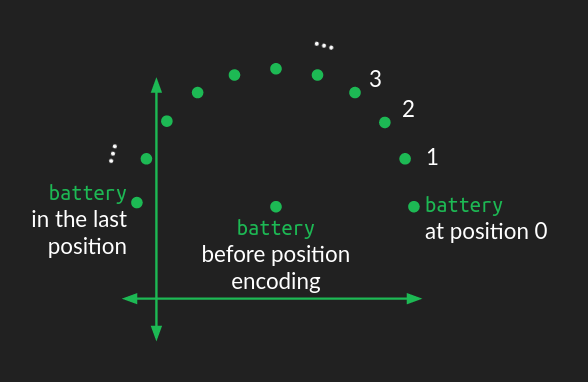' width='35%'></a><figcaption>Brandon Rohrer "Transformers from Scratch"</figcaption></figure>

<!--
持ったベクターをembeddingベクターに足します. Transformerの論文 [[4]](#scrollTo=zYDroE-YWKpi) では, 単語の位置に応じて様々な周波数で変化する$sin$, $cos$関数が使われました.

- 様々な周波数の三角関数を用いることで，embeddingの次元数 $d_{model}$ に合わせます．

- 例えば[この動画](https://www.youtube.com/watch?v=1biZfFLPRSY)は理解の助けになるでしょう．
-->

本演習では学習可能関数を用いるため，positional embeddingと呼びます．

なお，コード中に出てくるlogitとは，softmaxに通す前の未正規化スコアのことです．

$$
logit(p) = log(\frac{p}{1-p})  
$$

In [ ]:
class GPT(nn.Module):
    def __init__(self, config, embd_pdrop=0.1) -> None:
        """
        Parameters
        ----------
        embd_pdrop : float
            Embedding層のドロップアウト率
        """
        super().__init__()

        # 文字のidx（整数）と表現（ベクター）をつなぐルックアップテーブル
        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        # Positional encodingで足すベクターはゼロで初期化し, 学習可能なnn.Parameterとする
        self.pos_emb = nn.Parameter(torch.zeros(1, config.block_size, config.n_embd))
        # 確率0.1でランダムにtensorの要素をゼロにする
        self.drop = nn.Dropout(embd_pdrop)
        # n_layer個のブロックをnn.Sequentialで繋げる
        self.blocks = nn.Sequential(*[Block(config) for _ in range(config.n_layer)])
        # デコーダのhead
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        self.block_size = config.block_size

        # 引数で与えた関数をモデルのモジュールについて再起的に適用
        # https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.apply
        self.apply(self._init_weights)

    def forward(self, idx, targets=None):
        """
        Parameters
        ----------
        idx : torch.Tensor ( b, t )
            入力シークエンス（vocabulary内のインデックス）
        targets : torch.Tensor ( b, t )
            ターゲットシークエンス（vocabulary内のインデックス）
            GPTの場合入力シークエンスの全要素が一個ずつ前にずれたもの．

        Returns
        ----------
        logits : torch.Tensor ( b, t, vocab_size )
        loss : Optional[torch.Tensor] ( , )
            推論時はターゲットシークエンスを渡さずロスも計算しない．
        """
        b, t = idx.size()
        # 入力シークエンスがコンテクストサイズを超えていないことを保証
        assert t <= self.block_size, "Cannot forward, model block size is exhausted."

        # 文字のidx（整数）列を表現（ベクター）に変換
        token_embeddings = self.tok_emb(idx)  # ( b, t, d )
        position_embeddings = self.pos_emb[:, :t, :]  # ( 1, t, d )
        x = self.drop(token_embeddings + position_embeddings)  # ( b, t, d )

        # M個並んだTransformer blocksに入力
        x = self.blocks(x) # ( b, t, d )

        # GPT-2で追加された最後のlayer normalization
        x = self.ln_f(x) # ( b, t, d )

        logits = self.head(x) # ( b, t, vocab_size )

        # 訓練のときロス計算
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        else:
            loss = None

        return logits, loss

    def get_block_size(self):
        return self.block_size

    def _init_weights(self, module):
        """ nn.Moduleのクラスメソッドapplyから呼び，moduleに関して再起的に適用 """
        if isinstance(module, (nn.Linear, nn.Embedding)):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)

    def configure_optimizers(self, train_config):
        """
        各種パラメータを, AdamWによる更新式にL2正則化項を加えるものと加えないもの
        (biases, layer norm / embedding weights)の2グループに分け, 最後に
        PyTorchのoptimizerを返している. あまり重要ではない
        """
        decay = set()
        no_decay = set()
        whitelist_weight_modules = (torch.nn.Linear,)

        blacklist_weight_modules = (torch.nn.LayerNorm, torch.nn.Embedding)
        for mn, m in self.named_modules():
            for pn, p in m.named_parameters():
                fpn = '%s.%s' % (mn, pn) if mn else pn # full param name

                if pn.endswith('bias'):
                    # biasはweight decayされない
                    no_decay.add(fpn)
                elif pn.endswith('weight') and isinstance(m, whitelist_weight_modules):
                    # whitelistに入ったパラメータはweight decayされる
                    decay.add(fpn)
                elif pn.endswith('weight') and isinstance(m, blacklist_weight_modules):
                    # blacklistに入ったパラメータはweight decayされない
                    no_decay.add(fpn)

        # positional embeddingのパラメータはweight decayされない
        no_decay.add('pos_emb')

        # 見過ごされたパラメータが無いかチェック
        param_dict = {pn: p for pn, p in self.named_parameters()}
        inter_params = decay & no_decay
        union_params = decay | no_decay
        assert len(inter_params) == 0, "parameters %s made it into both decay/no_decay sets!" % (str(inter_params), )
        assert len(param_dict.keys() - union_params) == 0, "parameters %s were not separated into either decay/no_decay set!" \
                                                    % (str(param_dict.keys() - union_params), )

        optim_groups = [
            {"params": [param_dict[pn] for pn in sorted(list(decay))], "weight_decay": train_config.weight_decay},
            {"params": [param_dict[pn] for pn in sorted(list(no_decay))], "weight_decay": 0.0},
        ]
        optimizer = torch.optim.AdamW(optim_groups, lr=train_config.learning_rate, betas=train_config.betas)
        return optimizer

## 3.文章生成

`CharDataset`クラスは，インスタンス化のときにテキスト形式で文章データを受け取ります．

本実装では，`__getitem__()`内でモデルに与えるコンテクストの長さ`block_size`に切り出し，一文字ずつ文字の辞書のインデックスに置き換えるということを行っています．

In [ ]:
class CharDataset(Dataset):
    def __init__(self, data, block_size) -> None:
        """
        Parameters
        ----------
        data : str
            文章．今回は文字数約100万のテキストデータ
        block_size : int
            モデルに入力する最大系列長
        """
        # set型は重複しない要素のコレクション
        chars = sorted(list(set(data)))

        data_size, vocab_size = len(data), len(chars) # 1115394, 65
        print('Data has %d characters, %d unique:' % (data_size, vocab_size))
        print(chars)

        # 文字を0~64の数字にマップする辞書
        self.stoi = {ch: i for i, ch in enumerate(chars)}
        # 逆に, 数字を65種類の文字にマップする辞書
        self.itos = {i: ch for i, ch in enumerate(chars)}

        self.block_size = block_size
        self.vocab_size = vocab_size # 65
        self.data = data

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        """
        テキスト形式のまま保持しているself.dataからblock_sizeの長さの文字列を
        切り出し，vocabulary内のインデックスに変換して返す

        Parameters
        ----------
        idx : int
            テキストデータから切り出しを始める文字のインデックス

        Returns
        ----------
        x : torch.Tensor ( block_size (= t), )
            モデルに入力されるインデックス系列
        y : torch.Tensor ( block_size (= t), )
            ターゲットのインデックス系列．xが一つ前にずれたもの
        """
        # idxから始まる長さblock_size + 1の文字列を切り出す
        chunk = self.data[idx:idx + self.block_size + 1] # 例: 'First, '

        # 抜き出した文字列を一つずつインデックスにマッピング
        dix = [self.stoi[s] for s in chunk] # 例: [18, 47, 56, 57, 58, 1, ...]

        x = torch.tensor(dix[:-1], dtype=torch.long)
        y = torch.tensor(dix[1:], dtype=torch.long)

        return x, y

言語モデルの訓練には下記のTrainerを用います．

In [ ]:
logger = logging.getLogger(__name__)

class TrainerConfig:
    # 最適化のパラメータ
    max_epochs = 10
    batch_size = 64
    learning_rate = 3e-4
    betas = (0.9, 0.95)
    grad_norm_clip = 1.0
    weight_decay = 0.1  # 行列乗算に使用する重みにのみ適用
    # 学習率の減衰パラメータ：線形warmupの後、元の学習率の10%までcosine減衰
    lr_decay = False
    warmup_tokens = 375e6  # warmup_tokensとfinal_tokensの値はGPT-3論文に由来するが，他のケースでも適切な初期値とは限らない
    final_tokens = 260e9  # このトークン数を処理した時点で，学習率が始めの値の10%まで下がるようにする
    # チェックポイントの設定
    ckpt_path = None
    num_workers = 0  # DataLoader用

    def __init__(self, **kwargs):
        for k,v in kwargs.items():
            setattr(self, k, v)

class Trainer:

    def __init__(self, model, train_dataset, test_dataset, config):
        self.model = model
        self.train_dataset = train_dataset
        self.test_dataset = test_dataset
        self.config = config

        # システム上にあるすべてのGPUを使用
        self.device = 'cpu'
        if torch.cuda.is_available():
            self.device = torch.cuda.current_device()
            self.model = torch.nn.DataParallel(self.model).to(self.device)

    def save_checkpoint(self):
        # DataParallel Wrapperは生のモデルのオブジェクトを.moduleに保持する
        raw_model = self.model.module if hasattr(self.model, "module") else self.model
        logger.info("saving %s", self.config.ckpt_path)
        torch.save(raw_model.state_dict(), self.config.ckpt_path)

    def train(self):
        model, config = self.model, self.config
        raw_model = model.module if hasattr(self.model, "module") else model
        optimizer = raw_model.configure_optimizers(config)

        def run_epoch(split):
            is_train = split == 'train'
            model.train(is_train)
            data = self.train_dataset if is_train else self.test_dataset
            loader = DataLoader(data, shuffle=True, pin_memory=True,
                                batch_size=config.batch_size,
                                num_workers=config.num_workers)

            losses = []
            pbar = tqdm(enumerate(loader), total=len(loader)) if is_train else enumerate(loader)
            for it, (x, y) in pbar:

                # データを適切なデバイスに配置
                x = x.to(self.device)
                y = y.to(self.device)

                # 順伝播
                with torch.set_grad_enabled(is_train):
                    logits, loss = model(x, y)
                    loss = loss.mean()  # 複数GPUに分散している場合損失をまとめる
                    losses.append(loss.item())

                if is_train:

                    # 逆伝播およびパラメータ更新
                    model.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_norm_clip)
                    optimizer.step()

                    # 進捗に応じて学習率を減衰
                    if config.lr_decay:
                        self.tokens += (y >= 0).sum()  # このステップで処理されたトークン数（ラベルが -100 でないもの）
                        if self.tokens < config.warmup_tokens:
                            # 線形warmup
                            lr_mult = float(self.tokens) / float(max(1, config.warmup_tokens))
                        else:
                            # cosine学習率減衰
                            progress = float(self.tokens - config.warmup_tokens) / float(max(1, config.final_tokens - config.warmup_tokens))
                            lr_mult = max(0.1, 0.5 * (1.0 + math.cos(math.pi * progress)))
                        lr = config.learning_rate * lr_mult
                        for param_group in optimizer.param_groups:
                            param_group['lr'] = lr
                    else:
                        lr = config.learning_rate

                    # 進捗の表示
                    pbar.set_description(f"epoch {epoch+1} iter {it}: train loss {loss.item():.5f}. lr {lr:e}")

            if not is_train:
                test_loss = float(np.mean(losses))
                logger.info("test loss: %f", test_loss)
                return test_loss

        best_loss = float('inf')
        self.tokens = 0  # 学習率減衰に使用するカウンタ
        for epoch in range(config.max_epochs):

            run_epoch('train')
            if self.test_dataset is not None:
                test_loss = run_epoch('test')

            # テストlossに基づく早期終了・テストを行わない場合は常にチェックポイントを保存
            good_model = self.test_dataset is None or test_loss < best_loss
            if self.config.ckpt_path is not None and good_model:
                best_loss = test_loss
                self.save_checkpoint()



def top_k_logits(logits, k):
    v, ix = torch.topk(logits, k)
    out = logits.clone()
    out[out < v[:, [-1]]] = -float('Inf')
    return out

@torch.no_grad()
def sample(model, x, steps, temperature=1.0, sample=False, top_k=None):
    """
    x（shape: (b, t)）として与えられたインデックス列を条件として次のトークンを予測し，
    予測したトークンをその都度入力に追加しながらシークエンスを生成
    この方法の計算量は，ステップ数に対して線形のRNNと違い2乗のオーダーになる
    また，RNNのcontext sizeは無限なのに対し，block_size という有限のcontext sizeを持つ
    """
    block_size = model.get_block_size()
    model.eval()
    for k in range(steps):
        x_cond = x if x.size(1) <= block_size else x[:, -block_size:]  # 必要であればcontextを切り詰める
        logits, _ = model(x_cond)
        # 最終ステップのlogitを取り出し，温度でスケーリング（第2回補足参照）
        logits = logits[:, -1, :] / temperature
        # 必要に応じて確率を上位k個の選択肢に絞る
        if top_k is not None:
            logits = top_k_logits(logits, top_k)
        # softmaxを適用して確率に変換
        probs = F.softmax(logits, dim=-1)
        # 分布からサンプル or 最も確率の高いものを選ぶ
        if sample:
            ix = torch.multinomial(probs, num_samples=1)
        else:
            _, ix = torch.topk(probs, k=1, dim=-1)
        # シークエンスに追加して処理を継続
        x = torch.cat((x, ix), dim=1)

    return x


In [ ]:
# 訓練の準備

block_size = 128 # コンテクストの長さ

# 事前学習用データセット. ファイルは1.1MB程度
text = open('data/shakespeare.txt', 'r').read()
train_dataset = CharDataset(text, block_size)
print('=============最初の147文字==============')
print(text[:147])

args = Args({
    'vocab_size': train_dataset.vocab_size,
    'block_size': train_dataset.block_size,
    'n_layer': 8,
    'n_head': 8,
    'n_embd': 512,
})
model = GPT(args)  # あとでtrainerがモデルをGPUに移してくれる

# Trainerをインスタンス化
# batch_sizeを512にするとメモリ不足になる
tconf = TrainerConfig(
    max_epochs=2,
    batch_size=256,
    learning_rate=6e-4,
    lr_decay=True,
    warmup_tokens=512 * 20,
    final_tokens=2 * len(train_dataset) * block_size,
    num_workers=2
)

trainer = Trainer(model, train_dataset, None, tconf)

model_path = work_dir + '/models/trained_language_model.pth'

実装したモデルの訓練を行う場合は，下記のコードのコメントを外して実行します．デフォルトの設定で1~2時間かかります．上で指定したドライブの`model_path`に学習済みモデルがあるので，今回は実行しなくて大丈夫です．

In [ ]:
# trainer.train()
# # 学習したパラメータの保存
# torch.save(model.state_dict(), model_path)

それでは，事前学習済みモデルを使い文章をサンプリングしてみましょう．

毎ステップ`block_size`の長さのトークン列をモデルに入れてlogitsを計算し，ソフトマックスにかけて得られた多項分布から次のトークンをサンプリングする，ということを行っています．
- 詳細は`Trainer`の`sample()`

In [ ]:
# 英語で，文章の始まりを書いてみると，続きを生成してくれる
context = "A STUDENT:"

# 学習済みパラメータのロード
model.load_state_dict(torch.load(model_path))

# 文字列を整数（インデックス）の配列にする
x = torch.tensor([train_dataset.stoi[s] for s in context], dtype=torch.long)[None,...].to(trainer.device)

# xを学習済みモデルに入力し, 続きをサンプリングする
y = sample(model, x, steps=2000, sample=True, top_k=10)[0]

print(f'x: {x.shape}  y: {y.shape}\n')

# 整数（インデックス）の配列を文字列に戻す
completion = ''.join([train_dataset.itos[int(i)] for i in y])
print(completion)

In [ ]:
# この後ViTを動かすために，GPTモデルとcuda cacheを削除してVRAMを解放
del model, trainer
torch.cuda.empty_cache()

## 4.Vision Transformer(ViT)
ここからは，Transformerを画像タスクに利用できるようにしたVision Transformer(ViT)[[7]](#scrollTo=zYDroE-YWKpi)を実装していきます．

ViTの全体像は以下のようになっています．

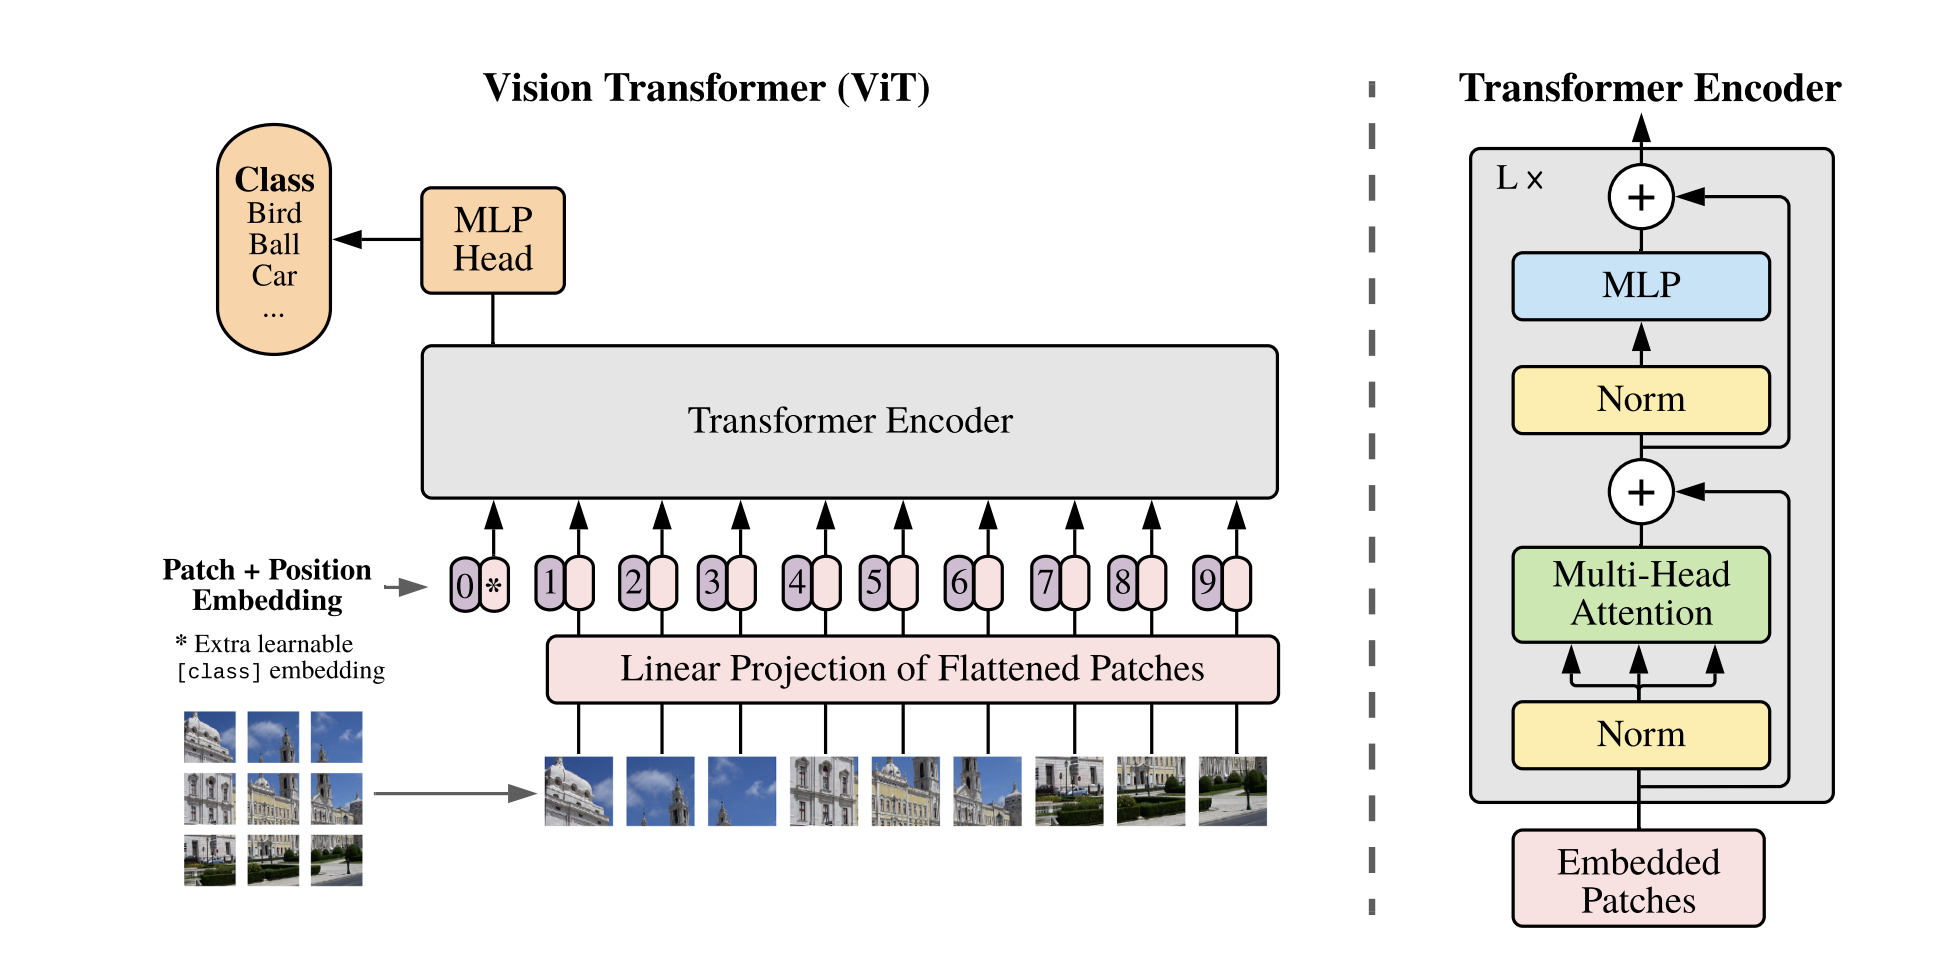

画像中のTransformer Encoder，Multi-Head Attentionは，GPT2で実装した`Block`クラス，`SelfAttention`クラスをそのまま利用することができます．

実装上の注意点：
- 講義中では言語TransformerとViTの違いとしてLayer Normalizationの場所が異なると説明しましたが，今回は`Block`クラスをPre Normで実装しているため，同じクラスを利用することができます．
- `SelfAttention`クラスをそのまま利用しますが，初期化時の引数`causal`を`False`にする必要があります．  

ViTの実装では以下の2つのクラスを追加で実装していきます．  
- `PatchEmbedding`: 画像をパッチに分割し，平坦化するためのクラス．
- `ViT`: `PatchEmbedding`クラスや`Block`クラス，`SelfAttention`クラスを組み合わせてViT全体を構成するクラス．

### 4.1.PatchEmbeddingの実装
まず，`PatchEmbedding`クラスを実装します．  

`PatchEmbedding`クラスは入力された画像をパッチに分割し平坦化し各パッチをembeddingした表現を返すクラスです．  
入力データの形状は(B, C, H, W)，パッチに分割した際のデータの形状は(B, N, p1 x p2 x C)となります（Nはパッチの枚数，p1とp2はパッチの高さと幅）．出力時にはこれを`embed_dim`の次元に埋め込むため，出力データの形状は(B, N, embed_dim)になります．

In [ ]:
# Patch Embeddingの実装
class PatchEmbedding(nn.Module):
    def __init__(self, image_size=[32, 32], patch_size=[2, 2], in_channels=3, embed_dim=192):
        """
        入力画像をパッチごとに埋め込むための層

        Parameters
        ----------
        image_size : Tuple[int]
            入力画像のサイズ
        patch_size : Tuple[int]
            各パッチのサイズ
        in_channels : int
            入力画像のチャネル数
        embed_dim : int
            埋め込み後の次元数
        """
        super().__init__()

        image_height, image_width = image_size
        patch_height, patch_width = patch_size

        assert image_height % patch_height == 0 and image_width % patch_width == 0, "パッチサイズは，入力画像のサイズを割り切れる必要があります．"

        num_patches = (image_height // patch_height) * (image_width // patch_width)  # パッチの数
        patch_dim = in_channels * patch_height * patch_width  # 各パッチを平坦化したときの次元数

        self.to_patch_embedding = nn.Sequential(
            Rearrange("b c (h p1) (w p2) -> b (h w) (p1 p2 c)", p1=patch_height, p2=patch_width),  # 画像をパッチに分割して平坦化
            nn.Linear(in_features=patch_dim, out_features=embed_dim),  # 埋め込みを行う
        )

    def forward(self, x):
        """
        Parameters
        ----------
        x : torch.Tensor (b, c, h, w)
            入力データ（画像）
        """
        return self.to_patch_embedding(x)  # (B, C, H, W) -> (B, num_patches, embed_dim)

### 4.2.ViTの実装
構成要素が揃ったため，それらを組み合わせて`ViT`クラスを実装していきます．

今回の実装ではほとんどGPT2と同じような実装になっていますが，パラメータの初期化，順伝播処理に違いがあるため，それらに注意して実装していきましょう．

In [ ]:
# ViTの実装
# GPT2からの変更点
# 1. 入力画像をパッチに分割するpatchifyを追加
# 2. クラストークンを追加
# 3. causal maskを利用しない，self-attentionに変更
class ViT(nn.Module):
    def __init__(self, config, embd_pdrop=0.1) -> None:
        """
        Parameters
        ----------
        embd_pdrop : float
            Embedding層のドロップアウト率
        """
        super().__init__()

        # ViT用に追加，修正
        num_patches = (config.image_size[0] // config.patch_size[0]) * (config.image_size[1] // config.patch_size[1])  # パッチの数（=系列長）
        self.cls_token = torch.nn.Parameter(torch.randn(1, 1, config.n_embd))  # クラストークンの初期化
        self.pos_emb = torch.nn.Parameter(torch.zeros(1, num_patches+1, config.n_embd))  # positional embeddingの初期化（クラストークンがあるためnum_patches+1になっていることに注意）
        self.patchify = PatchEmbedding(config.image_size, config.patch_size, 3, config.n_embd)  # 入力画像をパッチに分割するための層

        # 以下GPT2と同様の初期化
        # 確率0.1でランダムにtensorの要素をゼロにする
        self.drop = nn.Dropout(embd_pdrop)
        # n_layer個のブロックをnn.Sequentialで繋げる
        self.blocks = nn.Sequential(*[Block(config, causal=False) for _ in range(config.n_layer)])  # ViTのためcausal maskを利用しない点に注意
        # デコーダのhead
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.n_class, bias=False)

        self.block_size = num_patches

        # 引数で与えた関数をモデルのモジュールについて再起的に適用
        # https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.apply
        self.apply(self._init_weights)

    def forward(self, x, targets):
        """
        Parameters
        ----------
        x : torch.Tensor (b, c, h, w)
            入力データ（画像）
        y : torch.Tensor (b, )
            入力に対応する正解ラベル

        Returns
        -------
        logits : torch.Tensor (b, num classes)
            各クラスに対するロジット
        loss : torch.Tensor (1, )
            モデルの出力と正解ラベルから計算される損失の値
        """
        # 入力画像をパッチに分解
        x =  # WRITE ME
        b, n, _ = x.shape  # b: バッチサイズ n: パッチ数

        # クラストークンをバッチの数だけ作成
        cls_tokens = repeat(self.cls_token, "1 1 d -> b 1 d", b=b)

        # クラストークンを先頭に結合
        # (b, N, n_embd) -> (b, N+1, n_embd)
        x =  # WRITE ME

        # positional embeddingを加算
        position_embeddings = self.pos_emb[:, :(n+1), :]   # (1, N+1, d)
        x = self.drop(x + position_embeddings)  # ( b, N+1, d )

        # Transformerブロックに入力
        x = self.blocks(x)

        # clsトークンのみを抜き出す
        x = x[:, 0]  # (b, 1, d)

        # 予測クラスを出力
        logits = self.head(self.ln_f(x)).squeeze(dim=1)  # (b, n_class)

        # 訓練のときロス計算
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        else:
            loss = None

        return logits, loss

    def get_block_size(self):
        return self.block_size

    def _init_weights(self, module):
        """ nn.Moduleのクラスメソッドapplyから呼び，moduleに関して再起的に適用 """
        if isinstance(module, (nn.Linear, nn.Embedding)):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)

    def configure_optimizers(self, train_config):
        """
        各種パラメータを, AdamWによる更新式にL2正則化項を加えるものと加えないもの
        (biases, layer norm / embedding weights)の2グループに分け, 最後に
        PyTorchのoptimizerを返している. あまり重要ではない
        """
        decay = set()
        no_decay = set()
        whitelist_weight_modules = (torch.nn.Linear,)

        blacklist_weight_modules = (torch.nn.LayerNorm, torch.nn.Embedding)
        for mn, m in self.named_modules():
            for pn, p in m.named_parameters():
                fpn = '%s.%s' % (mn, pn) if mn else pn # full param name

                if pn.endswith('bias'):
                    # biasはweight decayされない
                    no_decay.add(fpn)
                elif pn.endswith('weight') and isinstance(m, whitelist_weight_modules):
                    # whitelistに入ったパラメータはweight decayされる
                    decay.add(fpn)
                elif pn.endswith('weight') and isinstance(m, blacklist_weight_modules):
                    # blacklistに入ったパラメータはweight decayされない
                    no_decay.add(fpn)

        # positional embeddingのパラメータはweight decayされない
        no_decay.add('pos_emb')
        no_decay.add('cls_token')

        # 見過ごされたパラメータが無いかチェック
        param_dict = {pn: p for pn, p in self.named_parameters()}
        inter_params = decay & no_decay
        union_params = decay | no_decay
        assert len(inter_params) == 0, "parameters %s made it into both decay/no_decay sets!" % (str(inter_params), )
        assert len(param_dict.keys() - union_params) == 0, "parameters %s were not separated into either decay/no_decay set!" \
                                                    % (str(param_dict.keys() - union_params), )

        optim_groups = [
            {"params": [param_dict[pn] for pn in sorted(list(decay))], "weight_decay": train_config.weight_decay},
            {"params": [param_dict[pn] for pn in sorted(list(no_decay))], "weight_decay": 0.0},
        ]
        optimizer = torch.optim.AdamW(optim_groups, lr=train_config.learning_rate, betas=train_config.betas)
        return optimizer

### 4.3.ViTの学習
最後にViTを学習させてみましょう．

データセットとして，画像分類タスクである[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html)を利用します．データセットの詳細は省略しますが，10クラス分類の画像データセットです．

まず画像の前処理の定義と，datasetの読み込みを行います．

In [ ]:
# 画像の前処理

# 訓練時はデータ拡張を行い、
# モデルが様々な画像変換に頑健になるようにする
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))]
)

# 検証／テスト時はデータ拡張せずに、
# 訓練時と同じ正規化のみ行い、純粋にモデル性能を評価する
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))]
)

# データセットの取得(CIFAR-10)
train_dataset = datasets.CIFAR10(root=".", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root=".", train=False, download=True, transform=test_transform)

では実際にViTを訓練させてみましょう．

利用するConfigやTrainerは同じものを利用していますが，VRAM容量の関係上重ねるブロックの数を半分にしています．

こちらの訓練にはGPT2ほど時間はかかりません（1エポック数分程度）．

In [ ]:
block_size = 256

args = Args({
    'image_size': [32, 32],
    'patch_size': [2, 2],
    'n_layer': 4,
    'n_head': 8,
    'n_embd': 512,
    'n_class': 10,
})
model = ViT(args)  # あとでtrainerがモデルをGPUに移してくれる

# Trainerをインスタンス化し, 訓練を開始
tconf = TrainerConfig(
    max_epochs=1,
    batch_size=256,
    learning_rate=6e-4,
    lr_decay=True,
    warmup_tokens=512 * 20,
    final_tokens=2 * len(train_dataset) * block_size,
    num_workers=2
)

trainer = Trainer(model, train_dataset, test_dataset, tconf)

model_path = work_dir + '/models/trained_vision_model.pth'

モデルの訓練を行う場合は，下記のコードのコメントを外して実行します．今回もドライブの`model_path`に学習済みモデルがあるので，実行しなくても大丈夫です．

In [ ]:
# trainer.train()
# # 学習したパラメータの保存
# torch.save(model.state_dict(), model_path)

最後に，訓練したViTの精度を確認しましょう．

In [ ]:
# datasetをdata loaderにする
train_dataloader = DataLoader(train_dataset, shuffle=True, pin_memory=True,
                              batch_size=tconf.batch_size, num_workers=tconf.num_workers)
test_dataloader = DataLoader(test_dataset, shuffle=True, pin_memory=True,
                             batch_size=tconf.batch_size, num_workers=tconf.num_workers)

device = "cuda" if torch.cuda.is_available() else "cpu"

# 学習したパラメータの読み込み
model.load_state_dict(torch.load(model_path))
model.eval()

train_acc, test_acc = 0., 0.
with torch.no_grad():
    for x, y in train_dataloader:
        x, y = x.to(device), y.to(device)
        logits, _ = model(x, y)

        acc = (torch.argmax(logits, dim=1) == y).float().sum().cpu()
        train_acc += acc

    for x, y in test_dataloader:
        x, y = x.to(device), y.to(device)
        logits, _ = model(x, y)

        acc = (torch.argmax(logits, dim=1) == y).float().sum().cpu()
        test_acc += acc

print(f"Train Acc.: {(train_acc / len(train_dataset)):.4f}")
print(f"Test Acc. : {(test_acc / len(test_dataset)):.4f}")

Transformerは帰納バイアスが弱いため，小規模なデータセットのみでの学習では，汎化性能が低くなることが知られています．

実際は大規模なデータセット([ImageNet](https://www.image-net.org/)や[JFT-300M](https://paperswithcode.com/dataset/jft-300m)など）を利用して事前学習したものを，タスクに応じてfine-tuningすることが一般的です．

## 参考文献

[[1]](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf) A. Radford et al., "Improving Language Understanding by Generative Pre-Training", OpenAI preprint, 2018

[[2]](https://d4mucfpksywv.cloudfront.net/better-language-models/language-models.pdf) A. Radford et al., "Language Models are Unsupervised Multitask Learners", OpenAI, 2019

[[3]](https://arxiv.org/abs/1706.03762) A. Vaswani et al., "Attention Is All You Need", arXiv preprint arXiv:1706.03762, 2017

[[4]](https://arxiv.org/abs/1607.06450) J. L. Ba et al., "Layer Normalization", arXiv preprint arXiv:1607.06450, 2016

[[5]](https://github.com/karpathy/minGPT) minGPT (a PyTorch re-implementation of GPT training) by [Andrej Karpathy](https://twitter.com/karpathy)

[[6]](https://e2eml.school/transformers.html) "Transformers from Scratch" by Brandon Rohrer

[[7]](https://arxiv.org/pdf/2010.11929) Dosovitskiy, A. et al., "An image is worth 16x16 words: Transformers for image recognition at scale", arXiv preprint arXiv:2010.11929, 2020

[[8]](https://github.com/lucidrains/vit-pytorch/tree/main) vit-pytorch(Implementetion of Viision Transformer) by Phil Wang
